In [1]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes




******STEP 1: UNDERSTAND THE DATA (VERY IMPORTANT)
🎯 Goal:Understand:What columns existWhich are numbers / textWhere missing values are******



In [5]:
#1. Check structure
df.info()
#Now observe 3 things carefully
# ✅ 1. Number of rows & columns
# Example:
# 7043 rows → customers
# 21 columns → features

# 2. Column types:
# Look at dtype
# object → text (categorical)
# int64 / float64 → numeric

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Check missing values**

In [6]:
df.isnull().sum()
# What to check:
# If any column has value > 0 → missing data
# If all are 0 → no missing values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**## Observations**

- Dataset has _7043_ rows and __21__ columns
- Contains both categorical and numerical features
- Target variable is 'Churn'(categorical data)

**Step 2: DATA CLEANING**

In [7]:
# Drop useless Columns
df = df.drop(columns=["customerID"])
# Why?
# customerID is just an ID
# It doesn’t help in prediction

#Convert target column
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})#Yes(churn)→1,,No(stay)→ 0

#Fix “TotalCharges” column
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
# It looks numeric but is actually text
# This converts it to numbers

#Handle missing values
df = df.fillna(df.mean(numeric_only=True))

#Convert simple categorical columns
df["gender"] = df["gender"].map({"Male": 0, "Female": 1})
#✅ Final check
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


**## Observations**

- Dataset has 7043 rows and 20 columns
- Contains both numerical and categorical features
- Target variable is Churn (converted to numeric)
- No missing values remain


**Step 3:Understand the Target**

In [9]:
df["Churn"].value_counts()
#0--> stayed  ,, 1--> lef

Churn
0    5174
1    1869
Name: count, dtype: int64

<Axes: xlabel='Churn'>

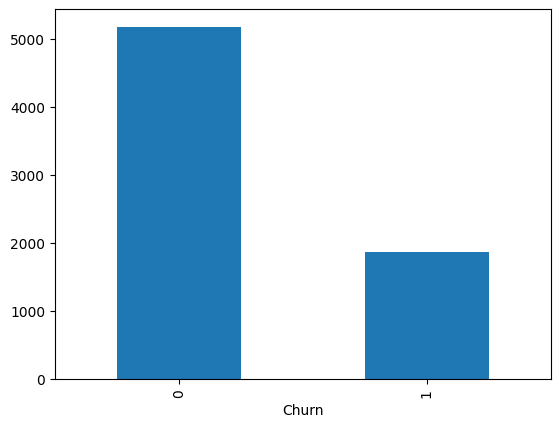

In [10]:
#Visualize
df["Churn"].value_counts().plot(kind="bar")
# ❓ Is data balanced?
# Answer:
# ❌ No

# 👉 Because:
# Stayed customers are much more
# Churn customers are less
# This means Dataset is imbalanced

**## Target Analysis**

- Majority of customers did not churn
- Dataset is imbalanced
- More 0s (stay) than 1s (churn)
